Using device: cpu
Epoch 1/50, Loss: 0.0828


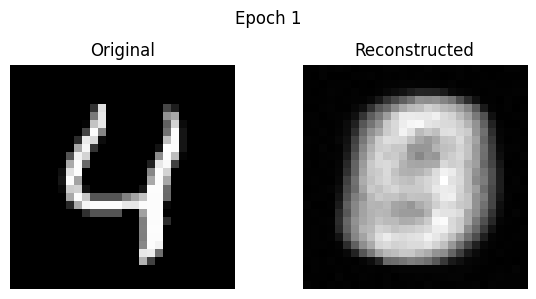

Epoch 2/50, Loss: 0.0566
Epoch 3/50, Loss: 0.0494
Epoch 4/50, Loss: 0.0426
Epoch 5/50, Loss: 0.0396
Epoch 6/50, Loss: 0.0371
Epoch 7/50, Loss: 0.0347
Epoch 8/50, Loss: 0.0330
Epoch 9/50, Loss: 0.0319
Epoch 10/50, Loss: 0.0310
Epoch 11/50, Loss: 0.0302


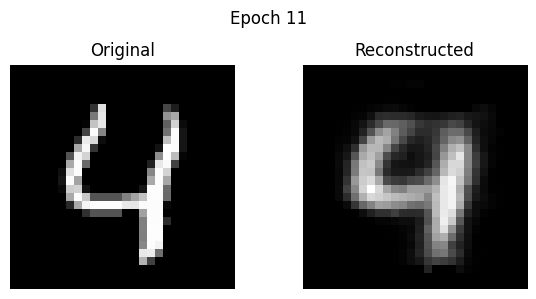

Epoch 12/50, Loss: 0.0296
Epoch 13/50, Loss: 0.0290
Epoch 14/50, Loss: 0.0285
Epoch 15/50, Loss: 0.0280
Epoch 16/50, Loss: 0.0275
Epoch 17/50, Loss: 0.0270
Epoch 18/50, Loss: 0.0266
Epoch 19/50, Loss: 0.0262
Epoch 20/50, Loss: 0.0258
Epoch 21/50, Loss: 0.0254


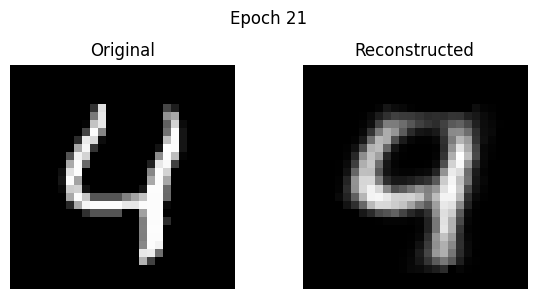

Epoch 22/50, Loss: 0.0249
Epoch 23/50, Loss: 0.0245
Epoch 24/50, Loss: 0.0241
Epoch 25/50, Loss: 0.0237
Epoch 26/50, Loss: 0.0234
Epoch 27/50, Loss: 0.0231
Epoch 28/50, Loss: 0.0228
Epoch 29/50, Loss: 0.0224
Epoch 30/50, Loss: 0.0221
Epoch 31/50, Loss: 0.0217


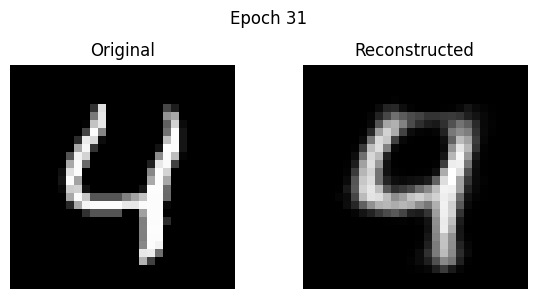

Epoch 32/50, Loss: 0.0214
Epoch 33/50, Loss: 0.0212
Epoch 34/50, Loss: 0.0209
Epoch 35/50, Loss: 0.0207
Epoch 36/50, Loss: 0.0206
Epoch 37/50, Loss: 0.0204
Epoch 38/50, Loss: 0.0202
Epoch 39/50, Loss: 0.0201
Epoch 40/50, Loss: 0.0199
Epoch 41/50, Loss: 0.0198


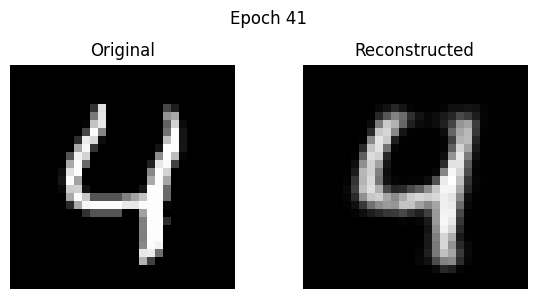

Epoch 42/50, Loss: 0.0196
Epoch 43/50, Loss: 0.0195
Epoch 44/50, Loss: 0.0194
Epoch 45/50, Loss: 0.0192
Epoch 46/50, Loss: 0.0191
Epoch 47/50, Loss: 0.0190
Epoch 48/50, Loss: 0.0189
Epoch 49/50, Loss: 0.0188
Epoch 50/50, Loss: 0.0187


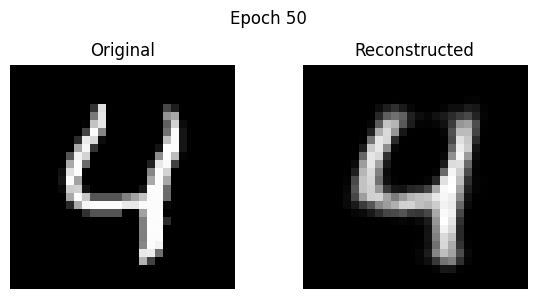

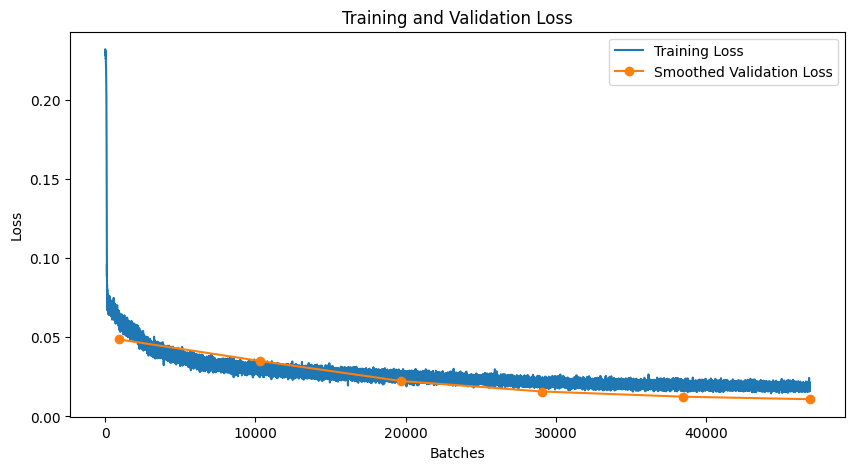

In [142]:
"""

This code implements a simple autoencoder using PyTorch to reconstruct MNIST images.

"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import tensorflow as tf
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter1d # To smooth the validation loss plot


# -------------------------
#       CONFIGURATION
# -------------------------
BATCH_SIZE = 64
LR = 1e-4
NUM_EPOCHS = 50
LATENT_SPACE_DIM = 15  # Dimensionality of the latent space. More dimension should make the reconstruction better.
VISUALIZATION_FREQ = 10  # Visualize reconstruction every X epochs

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}") # To remind mac users :(


# -------------------------
#       DATA LOADING
# -------------------------
def load_mnist_data() -> tuple[DataLoader, torch.Tensor]:
    """Load and preprocess the MNIST dataset.

    Returns:
        A tuple (train_loader, x_test):
            - train_loader: DataLoader for training data.
            - x_test: A torch.Tensor containing the normalized test images.
                these are the images that will be reconstructed to visualize the progress while training.
    """
    (x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

    # Normalize and reshape

    # Normalize, reshape and convert to torch.Tensor -> move to device
    x_train_torch = torch.tensor((x_train.reshape(-1, 28 * 28) / 255.0), dtype=torch.float32).to(DEVICE)
    x_test_torch = torch.tensor((x_test.reshape(-1, 28 * 28) / 255.0), dtype=torch.float32).to(DEVICE)

    # Create DataLoader
    # We dont need to handle x_test_torch further, we will use it only for visualization
    train_dataset = TensorDataset(x_train_torch)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    return train_loader, x_test_torch


# -------------------------
#       MODEL DEFINITION
# -------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim: int = 5) -> None:
        super().__init__()
        self.fc1 = nn.Linear(784, 250)
        self.fc2 = nn.Linear(250, 100)
        self.fc3 = nn.Linear(100, 25)
        self.fc4 = nn.Linear(25, latent_dim)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the encoder.
        Args:
            x: Input tensor of shape (batch_size, 784).

        Returns:
            Encoded features of shape (batch_size, latent_dim).
        """
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        return x


class Decoder(nn.Module):
    def __init__(self, latent_dim: int = 5) -> None:
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 25)
        self.fc2 = nn.Linear(25, 100)
        self.fc3 = nn.Linear(100, 250)
        self.fc4 = nn.Linear(250, 784)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the decoder.
        Args:
            x: Encoded features of shape (batch_size, latent_dim).

        Returns:
            Reconstructed input of shape (batch_size, 784).
        """
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        # Without sigmoid as the last activation function in the decoder, I experienced dead pixels in the output images
        # I dont see why, but makes sense to force the output to be in the range [0, 1] as it should.
        x = self.sigmoid(self.fc4(x)) 
        return x


class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int = 5) -> None:
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of the autoencoder (encode + decode).
        Args:
            x: Input tensor of shape (batch_size, 784).

        Returns:
            Reconstructed input of shape (batch_size, 784).
        """
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# -------------------------
#       TRAINING
# -------------------------
def visualize_reconstruction(
    model: nn.Module,
    x_test: torch.Tensor,
    sample_idx: int, # Index of the test sample to reconstruct.
    epoch: int
) -> None:
    """Visualize reconstruction of a single sample from x_test.
    Args:
        model: The autoencoder.
        x_test: Tensor of test samples (shape: [num_samples, 784]).
        sample_idx: Index of the test sample to reconstruct.
        epoch: Current epoch number.
    """
    model.eval()
    with torch.no_grad():
        original = x_test[sample_idx].unsqueeze(0) # Using sample_idx
        reconstructed = model(original)

    # Reshape for visualization
    original_img = original.cpu().numpy().reshape(28, 28)
    reconstructed_img = reconstructed.cpu().numpy().reshape(28, 28)

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_img, cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.suptitle(f"Epoch {epoch+1}")
    plt.tight_layout()
    plt.show()


def train_autoencoder(
    model: nn.Module,
    train_loader: DataLoader,
    x_test: torch.Tensor,
    num_epochs: int = NUM_EPOCHS,
    lr: float = LR,
    visualization_freq: int = VISUALIZATION_FREQ
) -> None:
    """Train the autoencoder on the MNIST dataset.
    Args:
        model: A PyTorch model instance (autoencoder).
        train_loader: DataLoader for the training set.
        x_test: Tensor of shape (num_test_samples, 784) for validation/reconstruction.
        num_epochs: Number of training epochs.
        lr: Learning rate for the optimizer.
        visualization_freq: How often (in epochs) to show reconstructions.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Empty lists to keep track of both train and validation losses
    train_losses = []
    val_losses = [] 
    val_epoch_indices = []

    ############ Training loop #############

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0

        for (x_batch,) in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, x_batch)
            loss.backward()
            optimizer.step()

    ########################################

            epoch_train_loss += loss.item()
            train_losses.append(loss.item()) # Get loss for each batch

        epoch_train_loss = epoch_train_loss / len(train_loader) # Average epoch training loss
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_train_loss:.4f}")

        # Validation & Visualization
        if (epoch % visualization_freq == 0) or (epoch == num_epochs - 1): # Second statement to include visualization in the last epoch
            model.eval()
            with torch.no_grad():
                sample_idx = 4 # Hardcoded sample index
                output_val = model(x_test[sample_idx].unsqueeze(0))
                val_loss = criterion(output_val, x_test[sample_idx].unsqueeze(0)).item()
                val_losses.append(val_loss)
                # train_losses and val_loss will have different lengths, so this is done to make it possible to still combine in a single plot
                val_epoch_indices.append(len(train_losses) - 1) 

            visualize_reconstruction(model, x_test, sample_idx, epoch) # Show reconstruction

    # Plot training and validation losses
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training Loss")
    smoothed_val_losses = gaussian_filter1d(val_losses, sigma=1)
    plt.plot(val_epoch_indices, smoothed_val_losses, label="Smoothed Validation Loss", marker='o')
    plt.xlabel("Batches")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()


def main() -> None:
    # Load data
    train_loader, x_test = load_mnist_data()

    # Initialize model and -> to device
    model = Autoencoder(latent_dim=LATENT_SPACE_DIM).to(DEVICE)

    # Train the model
    train_autoencoder(
        model=model,
        train_loader=train_loader,
        x_test=x_test,
        num_epochs=NUM_EPOCHS,
        lr=LR,
        visualization_freq=VISUALIZATION_FREQ
    )


if __name__ == "__main__":
    main()
